In [6]:
!pwd

/src/drone_causality/object_tracking


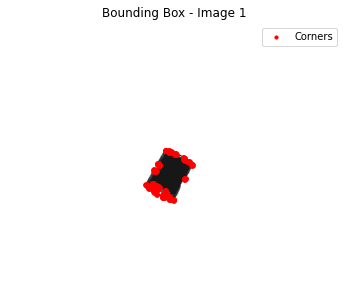

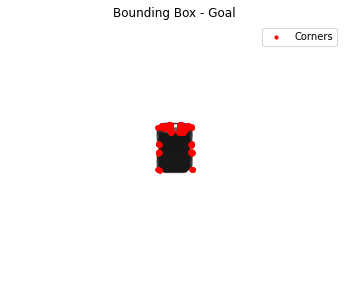

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load images
img1_path = "../gazebo_environment/markerless/output_images/Image100.png"
img2_path = "./goal_markerless_height3.png"
img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

def detect_marker_bounding_box(img, title):
    """ Detects strong Harris corners on the marker and plots a bounding box around them. """

    # Convert image to float32 and apply Harris Corner Detection
    gray = np.float32(img)
    dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

    # Dilate result to enhance corner detection
    dst = cv2.dilate(dst, None)

    # Extract strong corner points based on a threshold
    threshold = 0.01 * dst.max()
    corners = np.argwhere(dst > threshold)

    if len(corners) < 4:
        print("Not enough corners detected for bounding box.")
        return

    # Filter corners within a region of interest (ROI) to focus on the marker
    x_min, y_min = np.min(corners, axis=0)
    x_max, y_max = np.max(corners, axis=0)

    # Adjust ROI to better frame the marker
    roi_x_min = max(x_min - 5, 0)
    roi_y_min = max(y_min - 5, 0)
    roi_x_max = min(x_max + 5, img.shape[1])
    roi_y_max = min(y_max + 5, img.shape[0])

    # Plot detected bounding box around the marker
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap='gray')
    plt.scatter(corners[:, 1], corners[:, 0], c='red', s=10, label="Corners")

    # Draw bounding box
    # plt.plot([roi_y_min, roi_y_max, roi_y_max, roi_y_min, roi_y_min], 
    #          [roi_x_min, roi_x_min, roi_x_max, roi_x_max, roi_x_min], 
    #          'y-', lw=2, label="Bounding Box")

    plt.title(title)
    plt.legend()
    plt.axis("off")
    plt.show()

# Apply improved bounding box detection on both images
detect_marker_bounding_box(img1, "Bounding Box - Image 1")
detect_marker_bounding_box(img2, "Bounding Box - Goal")
